In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

# ==============================================================================
# 1. 백테스팅 기본 파라미터 설정
# ==============================================================================
START_DATE = "2000-01-01"
END_DATE = "2026-06-23"
INITIAL_CAPITAL = 10_000_000  # 초기 금액: 1,000만 원
MONTHLY_DEPOSIT = 1_000_000   # 매달 적립 금액: 100만 원

print(f"▶ 백테스팅 설정 완료: {START_DATE} ~ {END_DATE}")
print(f"▶ 초기 자산: {INITIAL_CAPITAL:,}원 | 매월 적립: {MONTHLY_DEPOSIT:,}원")

# ==============================================================================
# 2. 기초 자산 데이터 다운로드 및 추출 (버전별 MultiIndex 에러 완벽 차단)
# ==============================================================================
print("\n[1/3] 야후 파이낸스에서 QQQ 데이터를 가져오는 중...")
qqq_raw = yf.download("QQQ", start=START_DATE, end=END_DATE)

# 어떤 형태로 데이터가 와도 무조건 1차원 시리즈로 껍질을 벗겨낸 뒤 데이터프레임화합니다.
if 'Adj Close' in qqq_raw.columns:
    target_data = qqq_raw['Adj Close']
else:
    target_data = qqq_raw['Close']

# target_data가 데이터프레임이면 첫 번째 컬럼만 가져오고, 시리즈면 그대로 씁니다.
if isinstance(target_data, pd.DataFrame):
    df = target_data.iloc[:, 0].to_frame()
else:
    df = target_data.to_frame()

# 컬럼명을 깔끔하게 'QQQ'로 통일
df.columns = ['QQQ']

# ==============================================================================
# 3. 기술적 지표 및 기초 수익률 계산
# ==============================================================================
print("[2/3] 이동평균선 및 기초 수익률 계산 중...")
df['MA20'] = df['QQQ'].rolling(window=20).mean()
df['MA60'] = df['QQQ'].rolling(window=60).mean()
df['QQQ_Ret'] = df['QQQ'].pct_change().fillna(0)

# ==============================================================================
# 4. ⚠️ 장기 역산을 위한 가상(Synthetic) 레버리지 일일 수익률 생성
# (운용보수 및 금융 비용으로 인한 변동성 잠식 패널티 반영: QLD 연 2%, TQQQ 연 4%)
# ==============================================================================
df['Synthetic_QLD_Ret'] = (df['QQQ_Ret'] * 2) - (0.02 / 252)
df['Synthetic_TQQQ_Ret'] = (df['QQQ_Ret'] * 3) - (0.04 / 252)

# ==============================================================================
# 5. 매달 첫 거래일(현금 입금일) 판별 로직
# ==============================================================================
print("[3/3] 매월 첫 영업일(적립금 투입일) 체크 중...")
df['YearMonth'] = df.index.to_period('M')
# 각 달(YearMonth)에서 가장 첫 번째로 등장하는 행만 True로 표시
df['Is_First_Trading_Day'] = ~df['YearMonth'].duplicated(keep='first')

print("\n" + "="*50)
print(" Setup 완료! 데이터프레임 준비가 끝났습니다.")
print("="*50)
print(df[['QQQ', 'MA20', 'MA60', 'Is_First_Trading_Day']].head(25)) # 이동평균선이 생기는 20일 이후 흐름 확인용

[*********************100%***********************]  1 of 1 completed

▶ 백테스팅 설정 완료: 2000-01-01 ~ 2026-06-22
▶ 초기 자산: 10,000,000원 | 매월 적립: 1,000,000원

[1/3] 야후 파이낸스에서 QQQ 데이터를 가져오는 중...
[2/3] 이동평균선 및 기초 수익률 계산 중...
[3/3] 매월 첫 영업일(적립금 투입일) 체크 중...

 Setup 완료! 데이터프레임 준비가 끝났습니다.
                  QQQ       MA20  MA60  Is_First_Trading_Day
Date                                                        
2000-01-03  79.839661        NaN   NaN                  True
2000-01-04  74.362549        NaN   NaN                 False
2000-01-05  72.466637        NaN   NaN                 False
2000-01-06  67.489830        NaN   NaN                 False
2000-01-07  75.837158        NaN   NaN                 False
2000-01-10  77.943764        NaN   NaN                 False
2000-01-11  74.151901        NaN   NaN                 False
2000-01-12  72.519279        NaN   NaN                 False
2000-01-13  76.890457        NaN   NaN                 False
2000-01-14  78.681068        NaN   NaN                 False
2000-01-18  79.102356        NaN   NaN                 False
2

[*********************100%***********************]  1 of 1 completed

▶ 나스닥 100(QQQ) 데이터를 야후 파이낸스에서 다운로드 중...


▶ [Benchmarks] QQQ(1배) / QLD(2배) / TQQQ(3배) 순수 적립식 시뮬레이션 가동 중...
▶ TQQQ + MA 20 전략 시뮬레이션 가동 중...
▶ TQQQ + MA 60 전략 시뮬레이션 가동 중...
▶ TQQQ + MA 120 전략 시뮬레이션 가동 중...
▶ TQQQ + MA 240 전략 시뮬레이션 가동 중...


C:\Users\kmh12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kmh12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


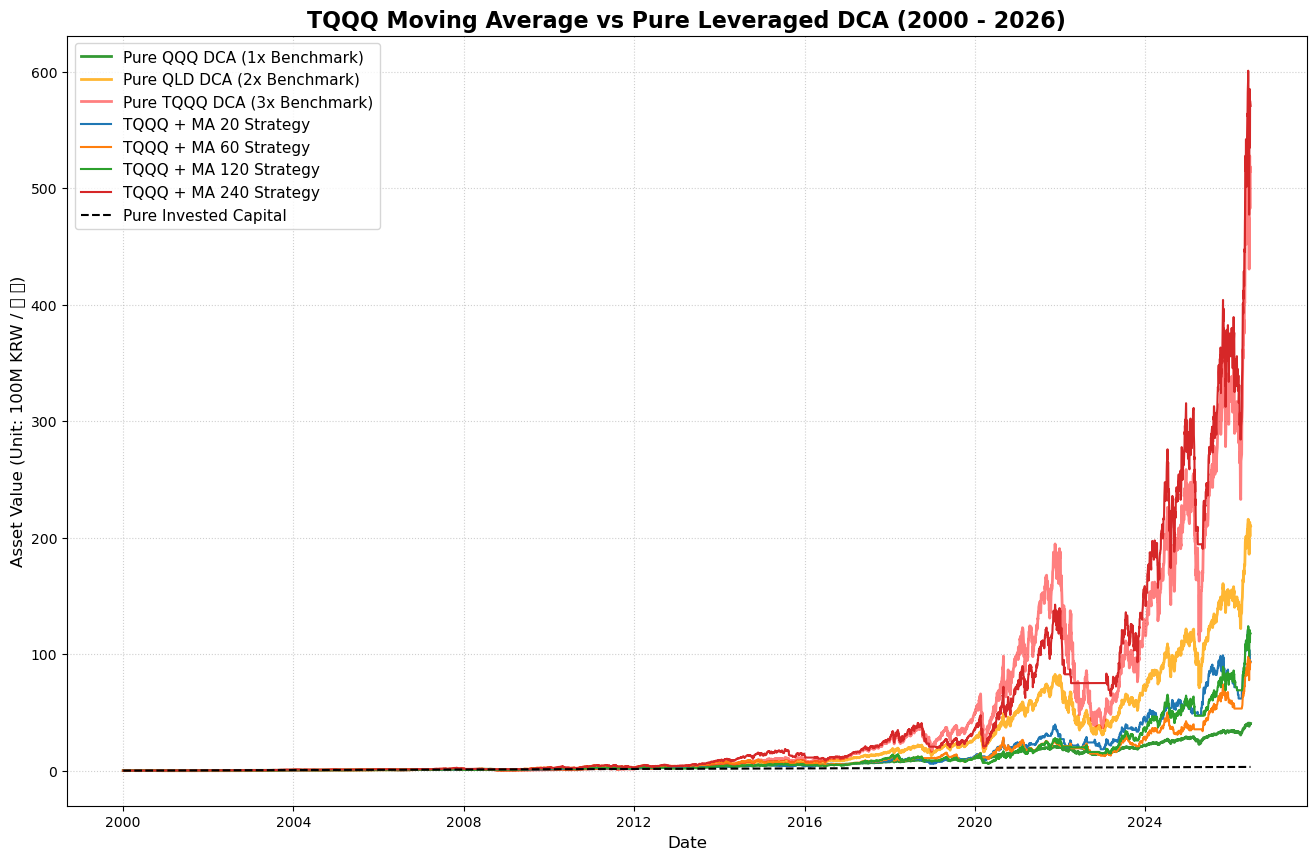


 🏆 최종 자산 스코어보드 (2026-06-22 기준)
총 투입 원금             : 32,700만 원
🟩 순수 QQQ (1배) 적립식 : 40.62억 원
🟨 순수 QLD (2배) 적립식 : 210.09억 원
🟥 순수 TQQQ(3배) 적립식 : 514.87억 원
------------------------------------------------------------
🔥 TQQQ + MA  20 전략    : 93.87억 원
🔥 TQQQ + MA  60 전략    : 92.92억 원
🔥 TQQQ + MA 120 전략    : 117.85억 원
🔥 TQQQ + MA 240 전략    : 570.80억 원


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. 백테스팅 기본 파라미터 및 데이터 세팅
# ==============================================================================
START_DATE = "2000-01-01"
END_DATE = "2026-06-23"  # 6월 22일까지 포함하기 위해 23일로 설정
INITIAL_CAPITAL = 10_000_000  # 초기 금액 1,000만 원
MONTHLY_DEPOSIT = 1_000_000   # 매달 충전 금액 100만 원

print("▶ 나스닥 100(QQQ) 데이터를 야후 파이낸스에서 다운로드 중...")
qqq_raw = yf.download("QQQ", start=START_DATE, end=END_DATE)

# 버전별 멀티인덱스 에러 방지 안전장치
target_data = qqq_raw['Adj Close'] if 'Adj Close' in qqq_raw.columns else qqq_raw['Close']
df = target_data.iloc[:, 0].to_frame() if isinstance(target_data, pd.DataFrame) else target_data.to_frame()
df.columns = ['QQQ']

# 기초 수익률 및 가상 QLD(2배), TQQQ(3배) 일일 수익률 생성 (연 비용 패널티 반영)
df['QQQ_Ret'] = df['QQQ'].pct_change().fillna(0)
df['Synthetic_QLD_Ret'] = (df['QQQ_Ret'] * 2) - (0.02 / 252)  # 연 2% 비용 차감
df['Synthetic_TQQQ_Ret'] = (df['QQQ_Ret'] * 3) - (0.04 / 252) # 연 4% 비용 차감

# 매월 첫 거래일(현금 입금일) 판별
df['YearMonth'] = df.index.to_period('M')
df['Is_First_Trading_Day'] = ~df['YearMonth'].duplicated(keep='first')

# 순수 원금 누적액 기록용
total_invested_history = []
cum_invested = INITIAL_CAPITAL

for i in range(len(df)):
    if df['Is_First_Trading_Day'].iloc[i] and i > 0:
        cum_invested += MONTHLY_DEPOSIT
    total_invested_history.append(cum_invested)
df['Total_Invested'] = total_invested_history

# ==============================================================================
# 2. 📊 순수 지수별 무지성 거치+적립식 (Benchmarks) 시뮬레이션
# ==============================================================================
print("▶ [Benchmarks] QQQ(1배) / QLD(2배) / TQQQ(3배) 순수 적립식 시뮬레이션 가동 중...")
qqq_dca_val = INITIAL_CAPITAL
qld_dca_val = INITIAL_CAPITAL
tqqq_dca_val = INITIAL_CAPITAL

qqq_dca_history = []
qld_dca_history = []
tqqq_dca_history = []

for i in range(len(df)):
    # 매달 첫 거래일에 100만 원 즉시 추가 매수
    if df['Is_First_Trading_Day'].iloc[i] and i > 0:
        qqq_dca_val += MONTHLY_DEPOSIT
        qld_dca_val += MONTHLY_DEPOSIT
        tqqq_dca_val += MONTHLY_DEPOSIT
        
    # 각각의 일일 수익률 반영
    qqq_dca_val *= (1 + df['QQQ_Ret'].iloc[i])
    qld_dca_val *= (1 + df['Synthetic_QLD_Ret'].iloc[i])
    tqqq_dca_val *= (1 + df['Synthetic_TQQQ_Ret'].iloc[i])
    
    qqq_dca_history.append(qqq_dca_val)
    qld_dca_history.append(qld_dca_val)
    tqqq_dca_history.append(tqqq_dca_val)

df['Benchmark_QQQ_DCA'] = qqq_dca_history
df['Benchmark_QLD_DCA'] = qld_dca_history
df['Benchmark_TQQQ_DCA'] = tqqq_dca_history

# ==============================================================================
# 3. 이평선별 전략 시뮬레이션 루프 실행 (20, 60, 120, 240)
# ==============================================================================
ma_list = [20, 60, 120, 240]
plt.figure(figsize=(16, 10))

# 벤치마크 지수들 차트 플로팅 (가독성을 위해 선 스타일과 두께 차별화)
plt.plot(df.index, df['Benchmark_QQQ_DCA'] / 100_000_000, 
         label='Pure QQQ DCA (1x Benchmark)', color='green', linewidth=2, alpha=0.8)
plt.plot(df.index, df['Benchmark_QLD_DCA'] / 100_000_000, 
         label='Pure QLD DCA (2x Benchmark)', color='orange', linewidth=2, alpha=0.8)
plt.plot(df.index, df['Benchmark_TQQQ_DCA'] / 100_000_000, 
         label='Pure TQQQ DCA (3x Benchmark)', color='red', linewidth=2, alpha=0.5)

for ma in ma_list:
    print(f"▶ TQQQ + MA {ma} 전략 시뮬레이션 가동 중...")
    
    # 이평선 계산 및 미래 참조 오류(.shift(1)) 차단 시그널 생성
    df[f'MA{ma}'] = df['QQQ'].rolling(window=ma).mean()
    df[f'Signal_{ma}'] = np.where(df['QQQ'] > df[f'MA{ma}'], 1, 0)
    df[f'Signal_{ma}'] = df[f'Signal_{ma}'].shift(1).fillna(0)
    
    # 자산 추적 변수 초기화
    cash_pool = INITIAL_CAPITAL
    stock_val = 0
    portfolio_history = []
    
    for i in range(len(df)):
        if df['Is_First_Trading_Day'].iloc[i] and i > 0:
            cash_pool += MONTHLY_DEPOSIT
            
        current_signal = df[f'Signal_{ma}'].iloc[i]
        
        if current_signal == 1:  # [상승장 조건 충족]
            if cash_pool > 0:
                stock_val += cash_pool
                cash_pool = 0
            stock_val *= (1 + df['Synthetic_TQQQ_Ret'].iloc[i]) # 전략은 조건 충족 시 TQQQ 매수
        else:  # [하락장 조건 미충족]
            if stock_val > 0:
                cash_pool += stock_val
                stock_val = 0
            
        portfolio_history.append(cash_pool + stock_val)
        
    df[f'Strat_MA{ma}'] = portfolio_history
    plt.plot(df.index, df[f'Strat_MA{ma}'] / 100_000_000, label=f'TQQQ + MA {ma} Strategy', linewidth=1.5)

# ==============================================================================
# 4. 시각화 및 최종 결과 출력
# ==============================================================================
# 순수 투입 원금 선 추가
plt.plot(df.index, df['Total_Invested'] / 100_000_000, label='Pure Invested Capital', color='black', linestyle='--')

plt.title('TQQQ Moving Average vs Pure Leveraged DCA (2000 - 2026)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Asset Value (Unit: 100M KRW / 억 원)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.show()

# 최종 스코어 브리핑
final_idx = df.index[-1]
print("\n" + "="*60)
print(f" 🏆 최종 자산 스코어보드 ({final_idx.strftime('%Y-%m-%d')} 기준)")
print("="*60)
print(f"총 투입 원금             : {df.loc[final_idx, 'Total_Invested'] / 10000:,.0f}만 원")
print(f"🟩 순수 QQQ (1배) 적립식 : {df.loc[final_idx, 'Benchmark_QQQ_DCA'] / 100_000_000:.2f}억 원")
print(f"🟨 순수 QLD (2배) 적립식 : {df.loc[final_idx, 'Benchmark_QLD_DCA'] / 100_000_000:.2f}억 원")
print(f"🟥 순수 TQQQ(3배) 적립식 : {df.loc[final_idx, 'Benchmark_TQQQ_DCA'] / 100_000_000:.2f}억 원")
print("-"*60)
for ma in ma_list:
    print(f"🔥 TQQQ + MA {ma:3d} 전략    : {df.loc[final_idx, f'Strat_MA{ma}'] / 100_000_000:.2f}억 원")
print("="*60)

▶ 나스닥 100(QQQ) 데이터를 다운로드 중...


[*********************100%***********************]  1 of 1 completed


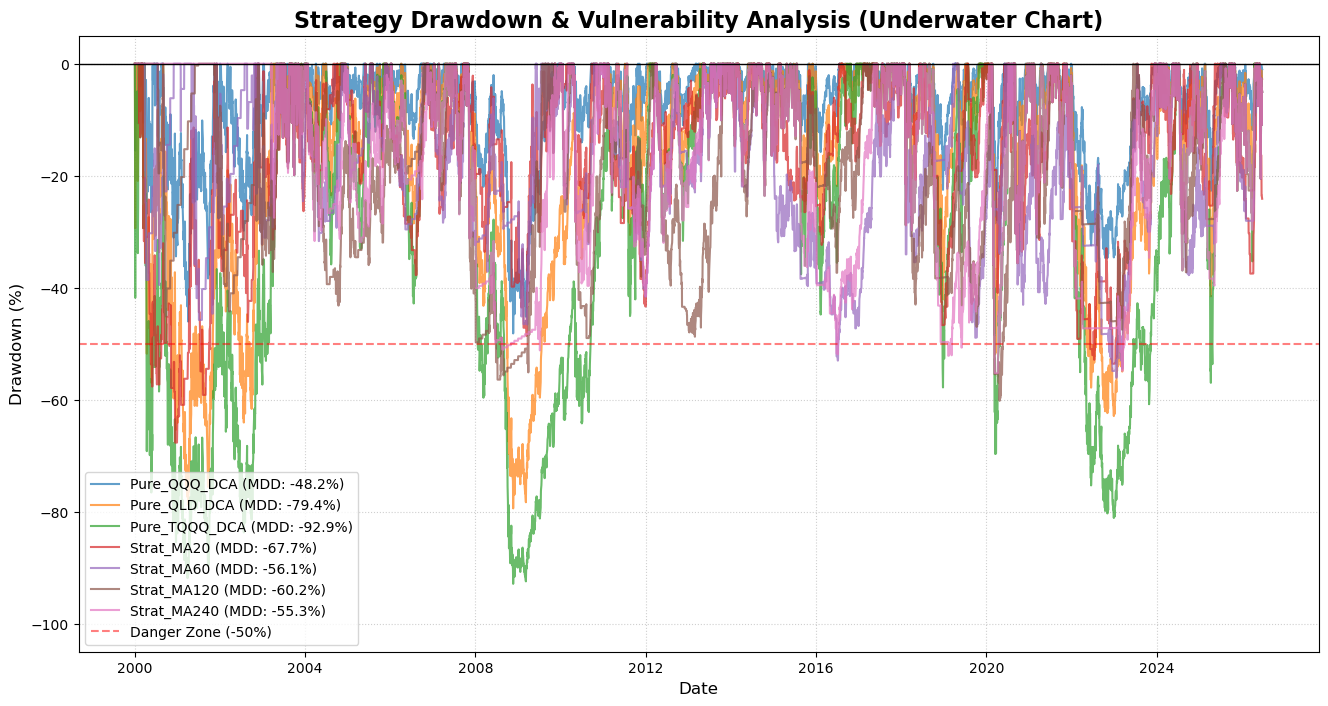


 📊 최종 성과 지표 요약본 (수익 vs 리스크 리포트)
🟩 순수 QQQ (1배)  | 최종 자산: 40.62억 원 | 역대 MDD: -48.2%
🟨 순수 QLD (2배)  | 최종 자산: 210.09억 원 | 역대 MDD: -79.4%
🟥 순수 TQQQ(3배)  | 최종 자산: 514.87억 원 | 역대 MDD: -92.9%
----------------------------------------------------------------------
🔥 TQQQ + MA 20    | 최종 자산: 93.87억 원 | 역대 MDD: -67.7%
🔥 TQQQ + MA 60    | 최종 자산: 92.92억 원 | 역대 MDD: -56.1%
🔥 TQQQ + MA 120   | 최종 자산: 117.85억 원 | 역대 MDD: -60.2%
🔥 TQQQ + MA 240   | 최종 자산: 570.80억 원 | 역대 MDD: -55.3%


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. 백테스팅 기본 파라미터 및 데이터 세팅
# ==============================================================================
START_DATE = "2000-01-01"
END_DATE = "2026-06-23"
INITIAL_CAPITAL = 10_000_000
MONTHLY_DEPOSIT = 1_000_000

print("▶ 나스닥 100(QQQ) 데이터를 다운로드 중...")
qqq_raw = yf.download("QQQ", start=START_DATE, end=END_DATE)

target_data = qqq_raw['Adj Close'] if 'Adj Close' in qqq_raw.columns else qqq_raw['Close']
df = target_data.iloc[:, 0].to_frame() if isinstance(target_data, pd.DataFrame) else target_data.to_frame()
df.columns = ['QQQ']

df['QQQ_Ret'] = df['QQQ'].pct_change().fillna(0)
df['Synthetic_QLD_Ret'] = (df['QQQ_Ret'] * 2) - (0.02 / 252)
df['Synthetic_TQQQ_Ret'] = (df['QQQ_Ret'] * 3) - (0.04 / 252)

df['YearMonth'] = df.index.to_period('M')
df['Is_First_Trading_Day'] = ~df['YearMonth'].duplicated(keep='first')

# 원금 누적 계산
total_invested_history = []
cum_invested = INITIAL_CAPITAL
for i in range(len(df)):
    if df['Is_First_Trading_Day'].iloc[i] and i > 0:
        cum_invested += MONTHLY_DEPOSIT
    total_invested_history.append(cum_invested)
df['Total_Invested'] = total_invested_history

# ==============================================================================
# 2. 순수 지수별 무지성 적립식 (Benchmarks) 시뮬레이션
# ==============================================================================
qqq_dca_val, qld_dca_val, tqqq_dca_val = INITIAL_CAPITAL, INITIAL_CAPITAL, INITIAL_CAPITAL
qqq_dca_history, qld_dca_history, tqqq_dca_history = [], [], []

for i in range(len(df)):
    if df['Is_First_Trading_Day'].iloc[i] and i > 0:
        qqq_dca_val += MONTHLY_DEPOSIT
        qld_dca_val += MONTHLY_DEPOSIT
        tqqq_dca_val += MONTHLY_DEPOSIT
    qqq_dca_val *= (1 + df['QQQ_Ret'].iloc[i])
    qld_dca_val *= (1 + df['Synthetic_QLD_Ret'].iloc[i])
    tqqq_dca_val *= (1 + df['Synthetic_TQQQ_Ret'].iloc[i])
    qqq_dca_history.append(qqq_dca_val)
    qld_dca_history.append(qld_dca_val)
    tqqq_dca_history.append(tqqq_dca_val)

df['Pure_QQQ_DCA'] = qqq_dca_history
df['Pure_QLD_DCA'] = qld_dca_history
df['Pure_TQQQ_DCA'] = tqqq_dca_history

# ==============================================================================
# 3. 이평선별 전략 시뮬레이션 루프 실행 (20, 60, 120, 240)
# ==============================================================================
ma_list = [20, 60, 120, 240]

for ma in ma_list:
    df[f'MA{ma}'] = df['QQQ'].rolling(window=ma).mean()
    df[f'Signal_{ma}'] = np.where(df['QQQ'] > df[f'MA{ma}'], 1, 0)
    df[f'Signal_{ma}'] = df[f'Signal_{ma}'].shift(1).fillna(0)
    
    cash_pool = INITIAL_CAPITAL
    stock_val = 0
    portfolio_history = []
    
    for i in range(len(df)):
        if df['Is_First_Trading_Day'].iloc[i] and i > 0:
            cash_pool += MONTHLY_DEPOSIT
            
        current_signal = df[f'Signal_{ma}'].iloc[i]
        if current_signal == 1:
            if cash_pool > 0:
                stock_val += cash_pool
                cash_pool = 0
            stock_val *= (1 + df['Synthetic_TQQQ_Ret'].iloc[i])
        else:
            if stock_val > 0:
                cash_pool += stock_val
                stock_val = 0
            
        portfolio_history.append(cash_pool + stock_val)
    df[f'Strat_MA{ma}'] = portfolio_history

# ==============================================================================
# 4. 🌟 [신규] 모든 전략의 Drawdown(낙폭) 및 MDD 계산
# ==============================================================================
target_strategies = [
    'Pure_QQQ_DCA', 'Pure_QLD_DCA', 'Pure_TQQQ_DCA',
    'Strat_MA20', 'Strat_MA60', 'Strat_MA120', 'Strat_MA240'
]

mdd_results = {}

# 하락률 차트를 그리기 위한 서브플롯 설정
fig, ax = plt.subplots(figsize=(16, 8))

for strat in target_strategies:
    # 역대 최고점(Peak) 계산
    rolling_peak = df[strat].cummax()
    # 최고점 대비 현재 낙폭 계산
    df[f'{strat}_DD'] = (df[strat] - rolling_peak) / rolling_peak
    # 역대 가장 깊은 낙폭(MDD) 추출
    mdd_results[strat] = df[f'{strat}_DD'].min() * 100
    
    # 차트 플로팅 (0% 선 아래로 얼마나 가라앉았는지 표시)
    ax.plot(df.index, df[f'{strat}_DD'] * 100, label=f'{strat} (MDD: {mdd_results[strat]:.1f}%)', alpha=0.7)

# 차트 디테일 설정
ax.set_title('Strategy Drawdown & Vulnerability Analysis (Underwater Chart)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.set_ylim(-105, 5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.axhline(-50, color='red', linestyle='--', alpha=0.5, label='Danger Zone (-50%)')
ax.legend(fontsize=10, loc='lower left')
plt.show()

# ==============================================================================
# 5. 최종 리스크 보고서 출력
# ==============================================================================
final_idx = df.index[-1]
print("\n" + "="*70)
print(f" 📊 최종 성과 지표 요약본 (수익 vs 리스크 리포트)")
print("="*70)
print(f"🟩 순수 QQQ (1배)  | 최종 자산: {df.loc[final_idx, 'Pure_QQQ_DCA']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Pure_QQQ_DCA']:.1f}%")
print(f"🟨 순수 QLD (2배)  | 최종 자산: {df.loc[final_idx, 'Pure_QLD_DCA']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Pure_QLD_DCA']:.1f}%")
print(f"🟥 순수 TQQQ(3배)  | 최종 자산: {df.loc[final_idx, 'Pure_TQQQ_DCA']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Pure_TQQQ_DCA']:.1f}%")
print("-"*70)
print(f"🔥 TQQQ + MA 20    | 최종 자산: {df.loc[final_idx, 'Strat_MA20']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Strat_MA20']:.1f}%")
print(f"🔥 TQQQ + MA 60    | 최종 자산: {df.loc[final_idx, 'Strat_MA60']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Strat_MA60']:.1f}%")
print(f"🔥 TQQQ + MA 120   | 최종 자산: {df.loc[final_idx, 'Strat_MA120']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Strat_MA120']:.1f}%")
print(f"🔥 TQQQ + MA 240   | 최종 자산: {df.loc[final_idx, 'Strat_MA240']/100_000_000:.2f}억 원 | 역대 MDD: {mdd_results['Strat_MA240']:.1f}%")
print("="*70)

[*********************100%***********************]  1 of 1 completed

▶ QQQ 데이터를 다운로드 중입니다...
▶ 10억 원 돌파 시점 시뮬레이션 가동...



 🎉 목표 금액 10억 원 달성 보고서
▶ 투자 시작일 : 2000-01-03
▶ 10억 달성일 : 2014-02-27
▶ ⏱️ 소요 기간 : 총 14년 1개월
▶ 당일까지 누적 투입 원금 :  2014-02-01 기준 약 1.82억 원


C:\Users\kmh12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kmh12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


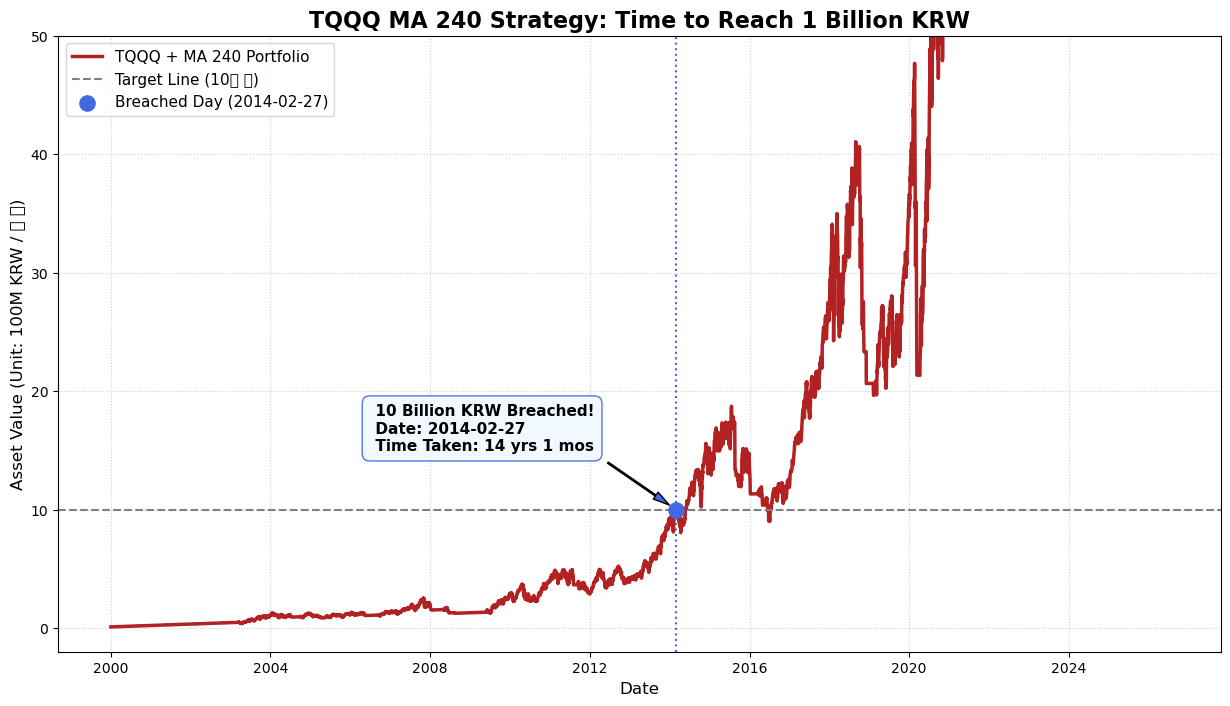

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. 기본 파라미터 및 데이터 세팅
# ==============================================================================
START_DATE = "2000-01-01"
END_DATE = "2026-06-23"
INITIAL_CAPITAL = 10_000_000  # 초기 금액 1,000만 원
MONTHLY_DEPOSIT = 1_000_000   # 매달 충전 금액 100만 원
TARGET_VALUE = 1_000_000_000  # 목표 금액: 10억 원

print("▶ QQQ 데이터를 다운로드 중입니다...")
qqq_raw = yf.download("QQQ", start=START_DATE, end=END_DATE)

target_data = qqq_raw['Adj Close'] if 'Adj Close' in qqq_raw.columns else qqq_raw['Close']
df = target_data.iloc[:, 0].to_frame() if isinstance(target_data, pd.DataFrame) else target_data.to_frame()
df.columns = ['QQQ']

# 일일 수익률 계산 (TQQQ는 패널티 반영)
df['QQQ_Ret'] = df['QQQ'].pct_change().fillna(0)
df['Synthetic_TQQQ_Ret'] = (df['QQQ_Ret'] * 3) - (0.04 / 252)

# 매월 첫 거래일 판별
df['YearMonth'] = df.index.to_period('M')
df['Is_First_Trading_Day'] = ~df['YearMonth'].duplicated(keep='first')

# MA 240 지표 및 미래 참조 오류 방지 시그널 생성
df['MA240'] = df['QQQ'].rolling(window=240).mean()
df['Signal_240'] = np.where(df['QQQ'] > df['MA240'], 1, 0)
df['Signal_240'] = df['Signal_240'].shift(1).fillna(0)

# ==============================================================================
# 2. 시뮬레이션 및 10억 원 돌파 타이밍 추적
# ==============================================================================
cash_pool = INITIAL_CAPITAL
stock_val = 0
portfolio_history = []

milestone_date = None  # 10억 최초 달성일 저장 변수

print("▶ 10억 원 돌파 시점 시뮬레이션 가동...")
for i in range(len(df)):
    if df['Is_First_Trading_Day'].iloc[i] and i > 0:
        cash_pool += MONTHLY_DEPOSIT
        
    current_signal = df['Signal_240'].iloc[i]
    
    if current_signal == 1:  # 상승장
        if cash_pool > 0:
            stock_val += cash_pool
            cash_pool = 0
        stock_val *= (1 + df['Synthetic_TQQQ_Ret'].iloc[i])
    else:  # 하락장
        if stock_val > 0:
            cash_pool += stock_val
            stock_val = 0
            
    current_total = cash_pool + stock_val
    portfolio_history.append(current_total)
    
    # 최초로 10억 원을 돌파하는 순간 기록
    if current_total >= TARGET_VALUE and milestone_date is None:
        milestone_date = df.index[i]

df['Strat_MA240'] = portfolio_history

# 소요 기간 계산 로직
if milestone_date:
    start_dt = df.index[0]
    total_days = (milestone_date - start_dt).days
    years = total_days // 365
    months = (total_days % 365) // 30
    
    print("\n" + "="*50)
    print(" 🎉 목표 금액 10억 원 달성 보고서")
    print("="*50)
    print(f"▶ 투자 시작일 : {start_dt.strftime('%Y-%m-%d')}")
    print(f"▶ 10억 달성일 : {milestone_date.strftime('%Y-%m-%d')}")
    print(f"▶ ⏱️ 소요 기간 : 총 {years}년 {months}개월")
    print(f"▶ 당일까지 누적 투입 원금 : {df.loc[milestone_date, 'YearMonth'].to_timestamp().to_pydatetime(): %Y-%m-%d} 기준 약 {((total_days//30)*1000000 + INITIAL_CAPITAL)/100_000_000:.2f}억 원")
    print("="*50)
else:
    print("\n❌ 시뮬레이션 기간 내에 10억 원을 달성하지 못했습니다.")

# ==============================================================================
# 3. 10억 돌파 시점 시각화 (그래프화)
# ==============================================================================
plt.figure(figsize=(15, 8))

# 자산 성장 곡선 (단위: 억 원)
plt.plot(df.index, df['Strat_MA240'] / 100_000_000, color='firebrick', linewidth=2.5, label='TQQQ + MA 240 Portfolio')

# 10억 원 목표선 (가로 점선)
plt.axhline(TARGET_VALUE / 100_000_000, color='gray', linestyle='--', linewidth=1.5, label='Target Line (10억 원)')

# 10억 달성 시점 강조 표시
if milestone_date:
    plt.axvline(milestone_date, color='royalblue', linestyle=':', linewidth=1.5)
    plt.scatter(milestone_date, TARGET_VALUE / 100_000_000, color='royalblue', s=120, zorder=5, 
                label=f"Breached Day ({milestone_date.strftime('%Y-%m-%d')})")
    
    # 그래프 내 텍스트 말풍선 추가
    plt.annotate(f" 10 Billion KRW Breached!\n Date: {milestone_date.strftime('%Y-%m-%d')}\n Time Taken: {years} yrs {months} mos",
                 xy=(milestone_date, TARGET_VALUE / 100_000_000),
                 xytext=(milestone_date - pd.Timedelta(days=2800), (TARGET_VALUE / 100_000_000) + 5),
                 fontsize=11, fontweight='bold', color='black',
                 bbox=dict(boxstyle='round,pad=0.5', fc='aliceblue', edgecolor='royalblue', alpha=0.9),
                 arrowprops=dict(facecolor='royalblue', shrink=0.08, width=1, headwidth=6))

plt.title('TQQQ MA 240 Strategy: Time to Reach 1 Billion KRW', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Asset Value (Unit: 100M KRW / 억 원)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# 10억 달성 초기 구간을 자세히 보기 위해 y축 범위를 적절히 제한 (최대 50억까지만 보이게 세팅)
plt.ylim(-2, 50) 

plt.show()